# E-OBS: TG, RR, PP processing

0.25° regular grid. Variables used: **TG** (mean temp), **RR** (precipitation), **PP** (pressure).

# Preprocess

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import xarray as xr
import eobs
import copy
import geopandas as gpd
import os
from pandas.tseries.offsets import MonthEnd

In [2]:
def display_netcdf_minimal(xarray):
    temp = copy.deepcopy(xarray)
    temp.attrs = {}
    display(temp)

In [3]:
# Eastern Norway bounds (matches ECMWF)
lat_min = 60.5
lat_max = 62.5
lon_min = 9.5
lon_max = 11.5

# -------- PreProcess ALL DATA --------

## Load Data

In [4]:
dataset_tg = eobs.load_netcdf_as_xarray(
    filename='tg_ens_mean_0.25deg_reg_v30.0e.nc',
    directory='data.nosync/eobs.nosync')

dataset_pp = eobs.load_netcdf_as_xarray(
    filename='pp_ens_mean_0.25deg_reg_v30.0e.nc',
    directory='data.nosync/eobs.nosync')

dataset_rr = eobs.load_netcdf_as_xarray(
    filename='rr_ens_mean_0.25deg_reg_v30.0e.nc',
    directory='data.nosync/eobs.nosync')

Loaded dataset from data.nosync/eobs.nosync/tg_ens_mean_0.25deg_reg_v30.0e.nc
Loaded dataset from data.nosync/eobs.nosync/pp_ens_mean_0.25deg_reg_v30.0e.nc
Loaded dataset from data.nosync/eobs.nosync/rr_ens_mean_0.25deg_reg_v30.0e.nc


In [5]:
for name, ds, var in [("tg", dataset_tg, "tg"), ("pp", dataset_pp, "pp"), ("rr", dataset_rr, "rr")]:
    print(f"{name}: {ds[var].attrs['units']} – {ds[var].attrs['long_name']}")

----- For tg -----
Celsius
mean temperature air_temperature

----- For pp -----
hPa
sea level pressure air_pressure_at_sea_level

----- For rr -----
mm
rainfall thickness_of_rainfall_amount


In [6]:
eobs.print_characteristics(dataset_tg, element='tg')

Time dimension size: (27210,)
Time granularity: 1 day
Time period: from 1950-01-01 to 2024-06-30

Longitude dimension size: (464,)
Latitude dimension size: (201,)

Precipitation dimensions: ('time', 'latitude', 'longitude')
Precipitation dimension size: (27210, 201, 464)
Precipitation unit: daily precipitation sum

Latitude min/max: 25.375 / 75.375
Longitude min/max: -40.375 / 75.375


In [7]:
eobs.print_characteristics(dataset_pp, element='pp')

Time dimension size: (27210,)
Time granularity: 1 day
Time period: from 1950-01-01 to 2024-06-30

Longitude dimension size: (464,)
Latitude dimension size: (201,)

Precipitation dimensions: ('time', 'latitude', 'longitude')
Precipitation dimension size: (27210, 201, 464)
Precipitation unit: daily precipitation sum

Latitude min/max: 25.375 / 75.375
Longitude min/max: -40.375 / 75.375


In [8]:
eobs.print_characteristics(dataset_rr, element='rr')

Time dimension size: (27210,)
Time granularity: 1 day
Time period: from 1950-01-01 to 2024-06-30

Longitude dimension size: (464,)
Latitude dimension size: (201,)

Precipitation dimensions: ('time', 'latitude', 'longitude')
Precipitation dimension size: (27210, 201, 464)
Precipitation unit: daily precipitation sum

Latitude min/max: 25.375 / 75.375
Longitude min/max: -40.375 / 75.375


# Step -1: Eastern Oslo Only

In [9]:
dataset_tg_eastnor = dataset_tg.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)
dataset_rr_eastnor = dataset_rr.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)
dataset_pp_eastnor = dataset_pp.sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
)
# Display dataset_pp_eastnor without the "history" attribute
tmp = copy.deepcopy(dataset_pp_eastnor); tmp.attrs = {}
tmp

<xarray.Dataset> Size: 7MB
Dimensions:    (time: 27210, latitude: 8, longitude: 8)
Coordinates:
  * latitude   (latitude) float64 64B 60.62 60.88 61.12 ... 61.88 62.12 62.38
  * longitude  (longitude) float64 64B 9.625 9.875 10.12 ... 10.88 11.12 11.38
  * time       (time) datetime64[ns] 218kB 1950-01-01 1950-01-02 ... 2024-06-30
Data variables:
    pp         (time, latitude, longitude) float32 7MB ...

In [10]:
print("min max lat lon in dataset", dataset_tg.latitude.values.min(), dataset_tg.latitude.values.max())
print("min max lon in dataset", dataset_tg.longitude.values.min(), " ", dataset_tg.longitude.values.max())
print("min max lat lon in eastnor", dataset_tg_eastnor.latitude.values.min(), " ", dataset_tg_eastnor.latitude.values.max())
print("min max lon in eastnor", dataset_tg_eastnor.longitude.values.min(), dataset_tg_eastnor.longitude.values.max())

min max lat lon in dataset 25.375 75.375
min max lon in dataset -40.375   75.375
min max lat lon in eastnor 60.625   62.375
min max lon in eastnor 9.625 11.375


In [ ]:
# To save up memory
del dataset_tg
del dataset_rr
del dataset_pp

# Map

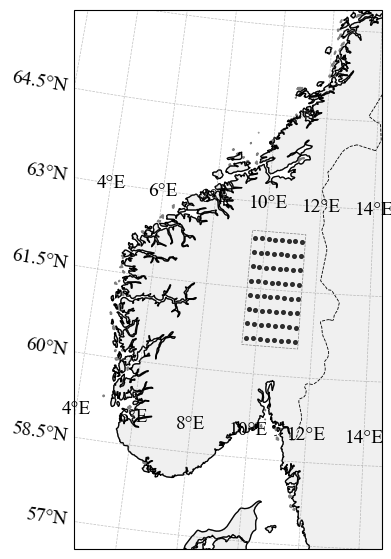

In [12]:
# --- 1. Define a projection suitable for the region ---
proj = ccrs.LambertConformal(central_longitude=18.0, central_latitude=64.5)

target_width = 7  # Change this number to resize everything at once!
scale_factor = target_width / 6.0  # Base scale relative to a standard 6-inch plot

# Calculate proportional sizes
base_fs = 10  # Base font size
figsize = (target_width, target_width)
fontsize_title = 14 * scale_factor
fontsize_label = 12 * scale_factor
fontsize_tick  = 12 * scale_factor

# Update global params: Font Family set to 'serif' to match LaTeX/Paper style
plt.rcParams.update({
    'font.family': 'serif',           # Use serif fonts (like Times/CM)
    'font.serif': ['Computer Modern Roman', 'Times New Roman', 'DejaVu Serif'], # Priority list
    'mathtext.fontset': 'cm',         # Use Computer Modern for math (if any)
    'font.size': fontsize_label,
    'axes.labelsize': fontsize_label,
    'axes.titlesize': fontsize_title,
    'xtick.labelsize': fontsize_tick,
    'ytick.labelsize': fontsize_tick,
    'legend.fontsize': fontsize_tick,
})


####################

fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})

# --- 3. Set the geographic extent ---
zoomed_extent = [4.5, 14, 57, 66]
ax.set_extent(zoomed_extent, crs=ccrs.PlateCarree())




# --- 7. Add Bounding Box ---
# Create a rectangle patch using the min/max coordinates
# lat_min, lat_max, lon_min, lon_max should be defined in your notebook (Cell 4)
width = lon_max - lon_min
height = lat_max - lat_min

rect = mpatches.Rectangle(
    (lon_min, lat_min), width, height,
    fill=False,             # Transparent background
    edgecolor='gray',       # Gray lines
    linestyle='--',         # Dashed style
    linewidth=0.5,          # Thickness
    transform=ccrs.PlateCarree(), # Important: coordinate system
    zorder=10               # Draw on top
)
ax.add_patch(rect)




# --- 4. Add features with a clean, grayscale aesthetic ---
ax.add_feature(cfeature.LAND, facecolor='#f0f0f0', edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='white', edgecolor='gray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.6)

# --- 5. Add gridlines and labels ---
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = False  # <--- Hides x-axis labels (longitude)

gl.ylabel_style = {'size': fontsize_tick, 'family': 'serif'}
gl.xlabel_style = {'size': fontsize_tick, 'family': 'serif'}

# --- 6. Plot the location dots only (no colormap) ---
# Select 1 timeinstance as requested
data_slice = dataset_tg_eastnor.isel(time=0)

lon_grid, lat_grid = np.meshgrid(data_slice.longitude.values, data_slice.latitude.values)

# Plot location points as slightly darker gray dots and make them smaller
slightly_more_dark_gray = '#222222'  # between '#1a1a1a' and '#303030', darker than before

# Flatten grids for scatter plotting
ax.scatter(
    lon_grid.flatten(), lat_grid.flatten(),
    color=slightly_more_dark_gray,
    edgecolor=slightly_more_dark_gray,
    s=7, marker='o',   # smaller size (was 16)
    transform=ccrs.PlateCarree(), zorder=5, alpha=0.9
)





# --- 7. Final Touches ---
# ax.set_title(f"E-OBS: Eastern Norway Locations", fontsize=fontsize_title)

########################################
path = "../Thesis/Figures/"
filename = "eobs_eastnor_locations.png"
plt.savefig(os.path.join(path, filename), bbox_inches='tight')
########################################

plt.show()

# Where are the NaNs?

### How many locations are only NaN vs partial NaN

In [13]:
for v, ds in zip(['tg', 'rr', 'pp'], [dataset_tg_eastnor, dataset_rr_eastnor, dataset_pp_eastnor]):
    vals = ds[v].values
    n_timesteps = vals.shape[0]
    nan_count = np.isnan(vals).sum(axis=0)
    tl = nan_count.size
    no_nan = (nan_count == 0).sum()
    all_nan = (nan_count == n_timesteps).sum()
    partial_nan = ((nan_count > 0) & (nan_count < n_timesteps)).sum()
    print(f"\n[{v}] 100% Valid: {no_nan} ({no_nan/tl*100:.1f}%) | 100% NaN: {all_nan} ({all_nan/tl*100:.1f}%) | Partial NaN: {partial_nan} ({partial_nan/tl*100:.1f}%) | {'✓ CLEAN' if partial_nan==0 else '⚠ MIXED'}")



[tg] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[rr] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[pp] 100% Valid: 62 (96.9%) | 100% NaN: 0 (0.0%) | Partial NaN: 2 (3.1%) | ⚠ MIXED


### What are these % for full timeseries vs only after 1993?
Note that these values are % of locations

In [14]:
# For each variable: print 1) full-dataset NaN/valid/partial stats, then 2) after-1994 stats, matching presentation.
for v, ds in zip(['tg', 'rr', 'pp'], [dataset_tg_eastnor, dataset_rr_eastnor, dataset_pp_eastnor]):
    print(f"\n[{v}] --- FULL DATASET ---")
    vals = ds[v].values  # shape: (time, lat, lon)
    n_timesteps = vals.shape[0]
    nan_count = np.isnan(vals).sum(axis=0)  # shape: (lat, lon)
    n_locations = nan_count.size
    no_nan = (nan_count == 0).sum()
    all_nan = (nan_count == n_timesteps).sum()
    partial_nan = ((nan_count > 0) & (nan_count < n_timesteps)).sum()
    print(f"[{v}] 100% Valid: {no_nan} ({no_nan / n_locations * 100:.1f}%) | 100% NaN: {all_nan} ({all_nan / n_locations * 100:.1f}%) | Partial NaN: {partial_nan} ({partial_nan / n_locations * 100:.1f}%) | {'✓ CLEAN' if partial_nan==0 else '⚠ MIXED'}")
    
    # Now for dataset after 1993
    print(f"\n[{v}] --- AFTER 1993-01-01 ---")
    if hasattr(ds, "time"):
        is_recent = np.array(ds.time.values) >= np.datetime64("1994-01-01")
        vals_recent = vals[is_recent]
        n_timesteps_recent = vals_recent.shape[0]
        # If no recent data, avoid divide-by-zero
        if n_timesteps_recent == 0:
            print("[No data after 1994-01-01]")
            continue
        nan_count_recent = np.isnan(vals_recent).sum(axis=0)  # (lat,lon)
        no_nan_recent = (nan_count_recent == 0).sum()
        all_nan_recent = (nan_count_recent == n_timesteps_recent).sum()
        partial_nan_recent = ((nan_count_recent > 0) & (nan_count_recent < n_timesteps_recent)).sum()
        print(f"[{v}|≥1994] 100% Valid: {no_nan_recent} ({no_nan_recent / n_locations * 100:.1f}%) | 100% NaN: {all_nan_recent} ({all_nan_recent / n_locations * 100:.1f}%) | Partial NaN: {partial_nan_recent} ({partial_nan_recent / n_locations * 100:.1f}%) | {'✓ CLEAN' if partial_nan_recent==0 else '⚠ MIXED'}")
    else:
        print(f"[{v}|≥1994] (no time axis found)")



[tg] --- FULL DATASET ---
[tg] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[tg] --- AFTER 1993-01-01 ---
[tg|≥1994] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[rr] --- FULL DATASET ---
[rr] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[rr] --- AFTER 1993-01-01 ---
[rr|≥1994] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[pp] --- FULL DATASET ---
[pp] 100% Valid: 62 (96.9%) | 100% NaN: 0 (0.0%) | Partial NaN: 2 (3.1%) | ⚠ MIXED

[pp] --- AFTER 1993-01-01 ---
[pp|≥1994] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN


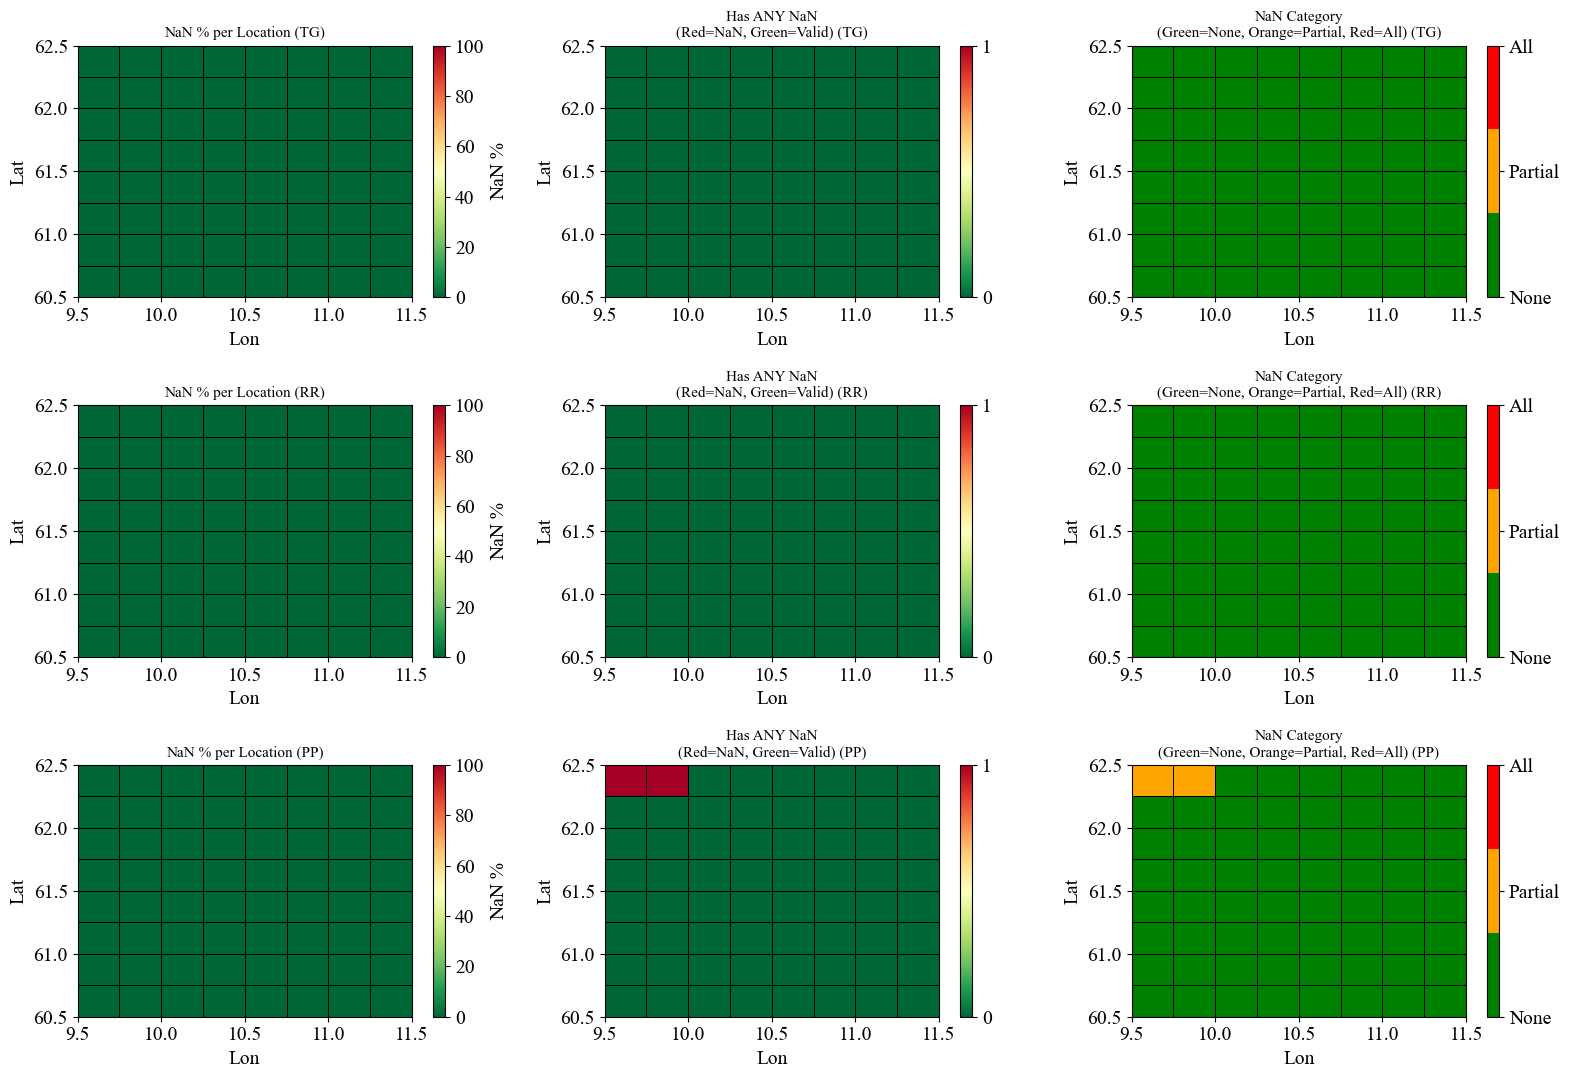

In [15]:
datasets = [('tg', dataset_tg_eastnor), ('rr', dataset_rr_eastnor), ('pp', dataset_pp_eastnor)]
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
titles = [
    'NaN % per Location', 
    'Has ANY NaN\n(Red=NaN, Green=Valid)',
    'NaN Category\n(Green=None, Orange=Partial, Red=All)'
]

for row, (var, ds) in enumerate(datasets):
    vals = ds[var].values
    n_timesteps = vals.shape[0]
    nan_count = np.isnan(vals).sum(axis=0)
    lat = ds.latitude.values
    lon = ds.longitude.values
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Plot 1: NaN %
    im1 = axes[row, 0].pcolormesh(lon_grid, lat_grid, (nan_count / n_timesteps) * 100, cmap='RdYlGn_r', vmin=0, vmax=100, edgecolors='k', linewidth=0.5)
    axes[row, 0].set_title(f'{titles[0]} ({var.upper()})', fontsize=11)
    axes[row, 0].set_xlabel('Lon'); axes[row, 0].set_ylabel('Lat')
    plt.colorbar(im1, ax=axes[row,0], label='NaN %')

    # Plot 2: Binary
    has_any_nan = (nan_count > 0).astype(int)
    im2 = axes[row, 1].pcolormesh(lon_grid, lat_grid, has_any_nan, cmap='RdYlGn_r', vmin=0, vmax=1, edgecolors='k', linewidth=0.5)
    axes[row, 1].set_title(f'{titles[1]} ({var.upper()})', fontsize=11)
    axes[row, 1].set_xlabel('Lon'); axes[row, 1].set_ylabel('Lat')
    plt.colorbar(im2, ax=axes[row,1], ticks=[0,1])

    # Plot 3: Ternary
    nan_cat = np.zeros_like(nan_count, dtype=int)
    nan_cat[nan_count == 0] = 0
    nan_cat[(nan_count > 0) & (nan_count < n_timesteps)] = 1
    nan_cat[nan_count == n_timesteps] = 2
    im3 = axes[row, 2].pcolormesh(lon_grid, lat_grid, nan_cat, cmap=ListedColormap(['green', 'orange', 'red']), vmin=0, vmax=2, edgecolors='k', linewidth=0.5)
    axes[row, 2].set_title(f'{titles[2]} ({var.upper()})', fontsize=11)
    axes[row, 2].set_xlabel('Lon'); axes[row, 2].set_ylabel('Lat')
    cbar = plt.colorbar(im3, ax=axes[row,2], ticks=[0,1,2])
    cbar.ax.set_yticklabels(['None', 'Partial', 'All'])

plt.tight_layout(); plt.show()

# Select from 1993 and onwards


In [13]:
dataset_rr_eastnor_1993 = dataset_rr_eastnor.sel(time=slice('1993-01-01', None))
dataset_tg_eastnor_1993 = dataset_tg_eastnor.sel(time=slice('1993-01-01', None))
dataset_pp_eastnor_1993 = dataset_pp_eastnor.sel(time=slice('1993-01-01', None))

tmp = copy.deepcopy(dataset_pp_eastnor_1993); tmp.attrs = {}
tmp


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 11504, latitude: 8, longitude: 8)
Coordinates:
  * latitude   (latitude) float64 64B 60.62 60.88 61.12 ... 61.88 62.12 62.38
  * longitude  (longitude) float64 64B 9.625 9.875 10.12 ... 10.88 11.12 11.38
  * time       (time) datetime64[ns] 92kB 1993-01-01 1993-01-02 ... 2024-06-30
Data variables:
    pp         (time, latitude, longitude) float32 3MB ...

# Analysis: Re-analyze from 1993 onwards

No NaN values at all after 1993 for eastnor (in contrast to fenno)


In [17]:
for v, ds in zip(['tg', 'rr', 'pp'], [dataset_tg_eastnor_1993, dataset_rr_eastnor_1993, dataset_pp_eastnor_1993]):
    vals = ds[v].values
    n_timesteps = vals.shape[0]
    nan_count = np.isnan(vals).sum(axis=0)
    tl = nan_count.size
    no_nan = (nan_count == 0).sum()
    all_nan = (nan_count == n_timesteps).sum()
    partial_nan = ((nan_count > 0) & (nan_count < n_timesteps)).sum()
    print(f"\n[{v}] 100% Valid: {no_nan} ({no_nan/tl*100:.1f}%) | 100% NaN: {all_nan} ({all_nan/tl*100:.1f}%) | Partial NaN: {partial_nan} ({partial_nan/tl*100:.1f}%) | {'✓ CLEAN' if partial_nan==0 else '⚠ MIXED'}")


[tg] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[rr] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN

[pp] 100% Valid: 64 (100.0%) | 100% NaN: 0 (0.0%) | Partial NaN: 0 (0.0%) | ✓ CLEAN


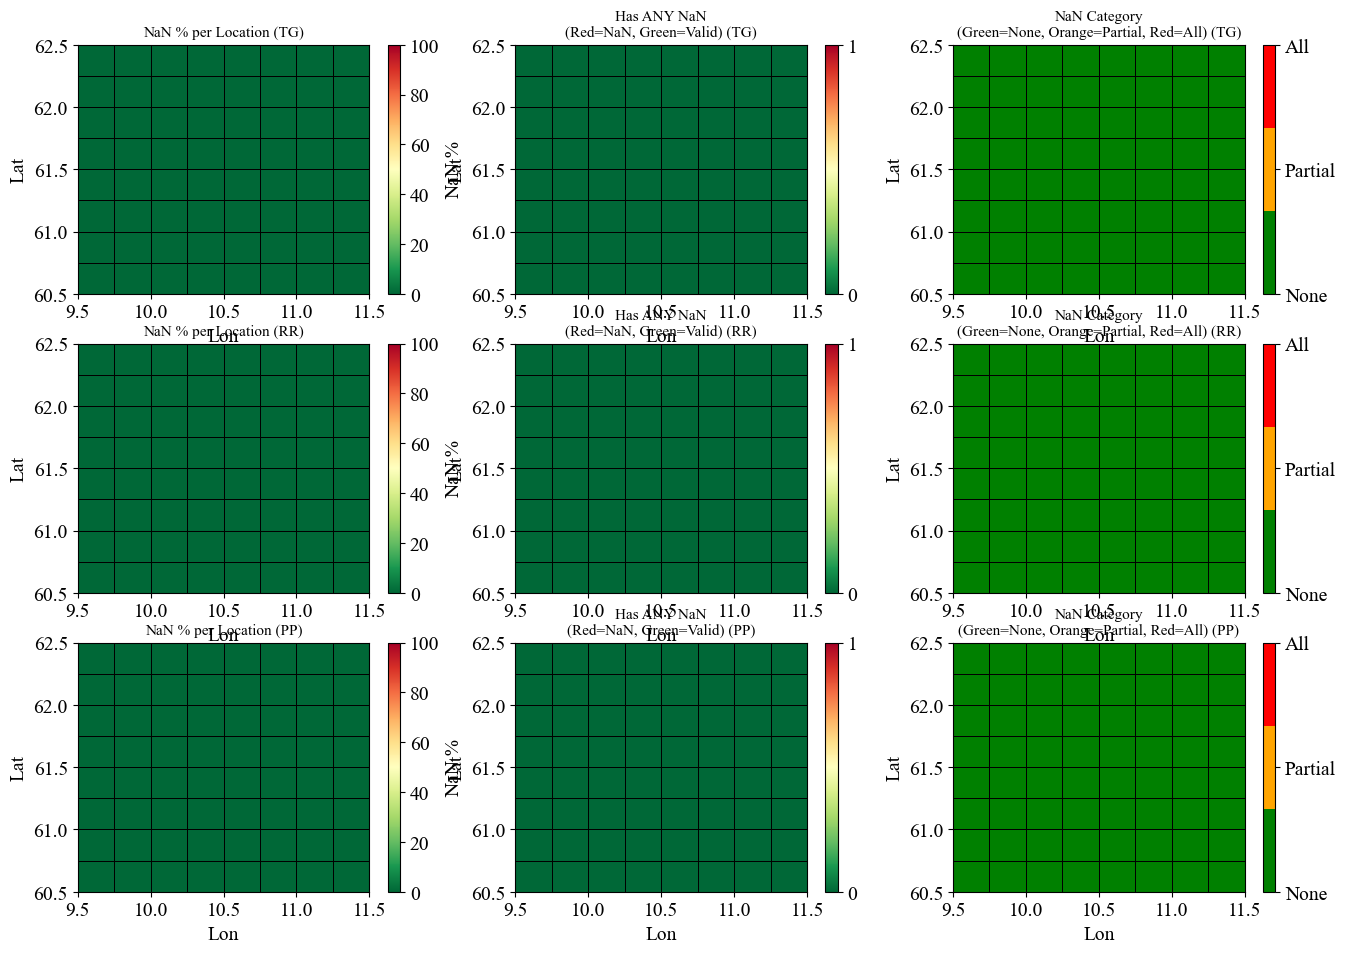

In [18]:
datasets = [('tg', dataset_tg_eastnor_1993), ('rr', dataset_rr_eastnor_1993), ('pp', dataset_pp_eastnor_1993)]
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
titles = [
    'NaN % per Location', 
    'Has ANY NaN\n(Red=NaN, Green=Valid)',
    'NaN Category\n(Green=None, Orange=Partial, Red=All)'
]

for row, (var, ds) in enumerate(datasets):
    vals = ds[var].values
    n_timesteps = vals.shape[0]
    nan_count = np.isnan(vals).sum(axis=0)
    lat = ds.latitude.values
    lon = ds.longitude.values
    lon_grid, lat_grid = np.meshgrid(lon, lat)

    # Plot 1: NaN %
    im1 = axes[row, 0].pcolormesh(lon_grid, lat_grid, (nan_count / n_timesteps) * 100, cmap='RdYlGn_r', vmin=0, vmax=100, edgecolors='k', linewidth=0.5)
    axes[row, 0].set_title(f'{titles[0]} ({var.upper()})', fontsize=11)
    axes[row, 0].set_xlabel('Lon'); axes[row, 0].set_ylabel('Lat')
    plt.colorbar(im1, ax=axes[row,0], label='NaN %')

    # Plot 2: Binary
    has_any_nan = (nan_count > 0).astype(int)
    im2 = axes[row, 1].pcolormesh(lon_grid, lat_grid, has_any_nan, cmap='RdYlGn_r', vmin=0, vmax=1, edgecolors='k', linewidth=0.5)
    axes[row, 1].set_title(f'{titles[1]} ({var.upper()})', fontsize=11)
    axes[row, 1].set_xlabel('Lon'); axes[row, 1].set_ylabel('Lat')
    plt.colorbar(im2, ax=axes[row,1], ticks=[0,1])

    # Plot 3: Ternary
    nan_cat = np.zeros_like(nan_count, dtype=int)
    nan_cat[nan_count == 0] = 0
    nan_cat[(nan_count > 0) & (nan_count < n_timesteps)] = 1
    nan_cat[nan_count == n_timesteps] = 2
    im3 = axes[row, 2].pcolormesh(lon_grid, lat_grid, nan_cat, cmap=ListedColormap(['green', 'orange', 'red']), vmin=0, vmax=2, edgecolors='k', linewidth=0.5)
    axes[row, 2].set_title(f'{titles[2]} ({var.upper()})', fontsize=11)
    axes[row, 2].set_xlabel('Lon'); axes[row, 2].set_ylabel('Lat')
    cbar = plt.colorbar(im3, ax=axes[row,2], ticks=[0,1,2])
    cbar.ax.set_yticklabels(['None', 'Partial', 'All'])

# plt.tight_layout(); plt.show()

# Resample to monthly - different operations for different variables


In [ ]:
dataset_tg_eastnor_1993_avgmonthly = dataset_tg_eastnor_1993.resample(time='1M').mean(skipna=True)
dataset_pp_eastnor_1993_avgmonthly = dataset_pp_eastnor_1993.resample(time='1M').mean(skipna=True)
dataset_rr_eastnor_1993_summonthly = dataset_rr_eastnor_1993.resample(time='1M').sum(skipna=False)

print(f"  TG: {dataset_tg_eastnor_1993_avgmonthly.dims}")
print(f"  PP: {dataset_pp_eastnor_1993_avgmonthly.dims}")
print(f"  RR: {dataset_rr_eastnor_1993_summonthly.dims}")

/usr/local/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(
/usr/local/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


✓ Monthly resampling complete
  TG: FrozenMappingWarningOnValuesAccess({'time': 378, 'latitude': 8, 'longitude': 8})
  PP: FrozenMappingWarningOnValuesAccess({'time': 378, 'latitude': 8, 'longitude': 8})
  RR: FrozenMappingWarningOnValuesAccess({'time': 378, 'latitude': 8, 'longitude': 8})


# Average across spatial dimensions (latitude, longitude)


In [ ]:
dataset_tg_eastnor_1993_avgmonthly_avgloc = dataset_tg_eastnor_1993_avgmonthly.mean(dim=['latitude', 'longitude'], skipna=True)
dataset_pp_eastnor_1993_avgmonthly_avgloc = dataset_pp_eastnor_1993_avgmonthly.mean(dim=['latitude', 'longitude'], skipna=True)
dataset_rr_eastnor_1993_summonthly_avgloc = dataset_rr_eastnor_1993_summonthly.mean(dim=['latitude', 'longitude'], skipna=True)

print(f"  TG: {dataset_tg_eastnor_1993_avgmonthly_avgloc.dims}")
print(f"  PP: {dataset_pp_eastnor_1993_avgmonthly_avgloc.dims}")
print(f"  RR: {dataset_rr_eastnor_1993_summonthly_avgloc.dims}")

display_netcdf_minimal(dataset_tg_eastnor_1993_avgmonthly_avgloc)

✓ Spatial aggregation complete
  TG: FrozenMappingWarningOnValuesAccess({'time': 378})
  PP: FrozenMappingWarningOnValuesAccess({'time': 378})
  RR: FrozenMappingWarningOnValuesAccess({'time': 378})


<xarray.Dataset> Size: 5kB
Dimensions:  (time: 378)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1993-01-31 1993-02-28 ... 2024-06-30
Data variables:
    tg       (time) float32 2kB -5.261 -4.457 -3.907 ... -0.06571 11.03 10.35

# Wet day frequency (WDF)

### Prepare WDF dataset (1993+ Eastern Norway)

In [ ]:
dataset_wdf_eastnor_1993 = dataset_rr_eastnor_1993.copy()

✓ WDF dataset prepared
  Time range: 1993-01-01T00:00:00.000000000 to 2024-06-30T00:00:00.000000000
  Shape: (11504, 8, 8)
  Region: Eastern Norway (lat 60.5-62.5, lon 9.5-11.5)


<xarray.Dataset> Size: 3MB
Dimensions:    (time: 11504, latitude: 8, longitude: 8)
Coordinates:
  * latitude   (latitude) float64 64B 60.62 60.88 61.12 ... 61.88 62.12 62.38
  * longitude  (longitude) float64 64B 9.625 9.875 10.12 ... 10.88 11.12 11.38
  * time       (time) datetime64[ns] 92kB 1993-01-01 1993-01-02 ... 2024-06-30
Data variables:
    rr         (time, latitude, longitude) float32 3MB ...

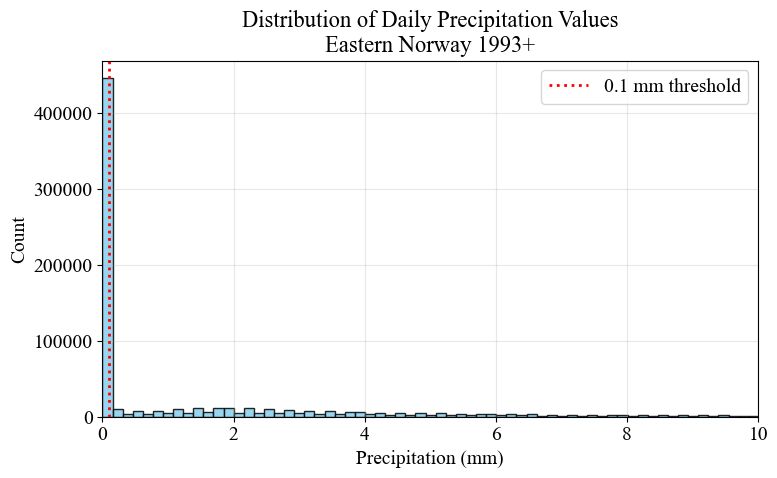

In [ ]:
import matplotlib.pyplot as plt

precip_values = dataset_wdf_eastnor_1993['rr'].values.flatten()
precip_values = precip_values[~np.isnan(precip_values)]

plt.figure(figsize=(8,5))
plt.hist(precip_values, bins=500, color='skyblue', edgecolor='k', alpha=0.85)
plt.axvline(0.1, color='red', linestyle=':', linewidth=2, label='0.1 mm threshold')
plt.title('Distribution of Daily Precipitation Values\nEastern Norway 1993+')
plt.xlabel('Precipitation (mm)')
plt.ylabel('Count')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(0, 10)
plt.tight_layout()
plt.show()


## Choosing a wet-day threshold (bin-free diagnostics)


/var/folders/kr/14bnw07j4rl47c8fc6dkk36m0000gn/T/ipykernel_8506/842890420.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


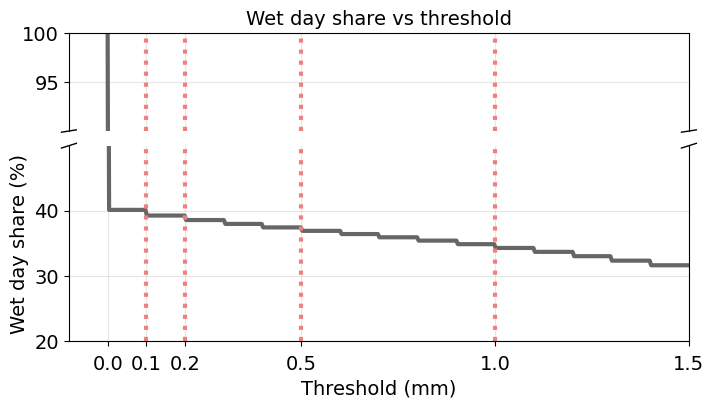

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

precip = precip_values.copy()
precip = precip[~np.isnan(precip)]
precip = precip[precip >= 0]

s = np.sort(precip)
n = s.size

# Threshold range to inspect (focus near 0)
threshold_grid = np.linspace(0.0, 1.5, 401)

# ECDF: P(rr <= t)
idx_right = np.searchsorted(s, threshold_grid, side="right")
df_ecdf = idx_right / n  # P(rr <= t)

# Wet-day share under two common conventions
wf_strict = 1.0 - df_ecdf  # P(rr > t)
idx_left = np.searchsorted(s, threshold_grid, side="left")
wf_ge = 1.0 - (idx_left / n)  # P(rr >= t)

p_zero = float(np.mean(s == 0.0))  # mass at exactly 0 mm

# "Knee" estimate (max distance from line between endpoints) on ECDF curve
x = threshold_grid
y = df_ecdf
x_n = (x - x.min()) / (x.max() - x.min())
y_n = (y - y.min()) / (y.max() - y.min() + 1e-12)
line = y_n[0] + (y_n[-1] - y_n[0]) * (x_n - x_n[0]) / (x_n[-1] - x_n[0])
dist = y_n - line
knee_idx = int(np.argmax(dist))
knee_t = float(x[knee_idx])

# Reference thresholds commonly used in practice
ref_thresholds = [0.1, 0.2, 0.5, 1.0]

_font_keys = ["font.family", "font.serif", "font.sans-serif", "mathtext.fontset"]
_old_fonts = {k: plt.rcParams[k] for k in _font_keys}
for k in _font_keys:
    plt.rcParams[k] = plt.rcParamsDefault[k]

fig, (ax_top, ax_bot) = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=(8, 4),
    gridspec_kw={"height_ratios": [1, 2], "hspace": 0.1},
)

for ax in (ax_top, ax_bot):
    ax.plot(threshold_grid, wf_ge * 100, color="0.4", lw=3, linestyle="-")
    ax.grid(alpha=0.3)

    for t in ref_thresholds:
        ax.axvline(t, color="lightcoral", linestyle=":", lw=3)
ax_bot.set_ylim(20, 50)
ax_top.set_ylim(90, 100)

# Explicit ticks to avoid label crowding at the break
ax_bot.set_yticks([20, 30, 40])
ax_top.set_yticks([95, 100])  # hide 90 to avoid clutter at the split

# Ensure key thresholds (incl. 0.1) appear on the x-axis
ax_bot.set_xticks([0.0, 0.1, 0.2, 0.5, 1.0, 1.5])
ax_bot.set_xlim(-0.1, 1.5)  # small left margin so x=0 and labels are visible

ax_bot.tick_params(axis="x", pad=6)

# Labels/titles
ax_top.set_title("Wet day share vs threshold", fontsize=14)
ax_bot.set_xlabel("Threshold (mm)", fontsize=14)
ax_bot.set_ylabel("Wet day share (%)", fontsize=14)

ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)

ax_top.tick_params(labeltop=False, bottom=False)
ax_bot.tick_params(top=False)

d = 0.012
kwargs = dict(color="k", clip_on=False, lw=1)
ax_top.plot((-d, +d), (-d, +d), transform=ax_top.transAxes, **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), transform=ax_top.transAxes, **kwargs)
ax_bot.plot((-d, +d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)
ax_bot.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=ax_bot.transAxes, **kwargs)

plt.tight_layout()
plt.show()

Sampled 3,453 precipitation measurements
  (3 locations × every 10th day, from 1993+ Eastern Norway data)


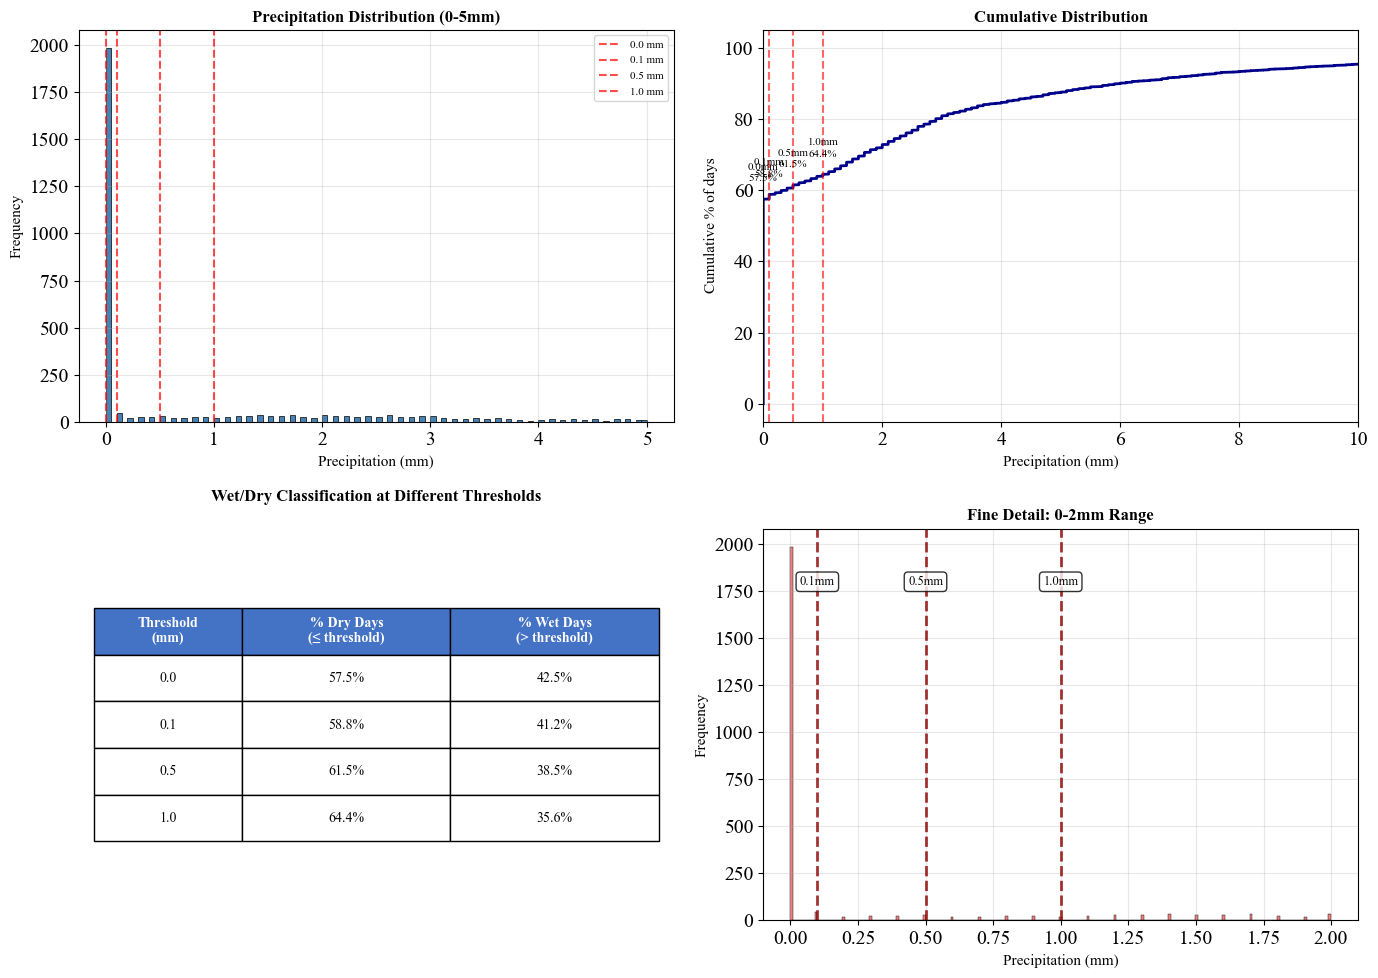


THRESHOLD RECOMMENDATIONS:
• 0.1 mm: Standard meteorological threshold (WMO), captures light drizzle
• 1.0 mm: Good for 'measurable' precipitation, filters trace amounts
• 2.5 mm: For 'significant' rain events only

→ Using 0.1 mm threshold (standard in meteorology)


In [15]:
# Threshold Analysis: Explore wet/dry threshold distribution on 1993+ Eastern Norway data
import numpy as np
import matplotlib.pyplot as plt

# Sample 3 random locations from the filtered dataset, subsample every 10th day for speed
np.random.seed(123)
lats = dataset_wdf_eastnor_1993['latitude'].values
lons = dataset_wdf_eastnor_1993['longitude'].values
n_sample = 3
random_indices = np.random.choice(len(lats) * len(lons), size=n_sample, replace=False)

all_precip = []
for idx in random_indices:
    lat_idx = idx // len(lons)
    lon_idx = idx % len(lons)
    lat, lon = lats[lat_idx], lons[lon_idx]
    
    data = dataset_wdf_eastnor_1993['rr'].sel(latitude=lat, longitude=lon).values
    data_subsample = data[::10]  # Every 10th day
    valid_data = data_subsample[~np.isnan(data_subsample) & (data_subsample >= 0)]
    all_precip.extend(valid_data)

all_precip = np.array(all_precip)
print(f"Sampled {len(all_precip):,} precipitation measurements")
print(f"  (3 locations × every 10th day, from 1993+ Eastern Norway data)")

# Test different thresholds
thresholds = [0.0, 0.1, 0.5, 1.0]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Histogram 0-5mm range
ax1 = axes[0, 0]
ax1.hist(all_precip[(all_precip >= 0) & (all_precip <= 5)], bins=100, color='steelblue', edgecolor='black', linewidth=0.5)
for thresh in thresholds:
    if thresh <= 5:
        ax1.axvline(thresh, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label=f'{thresh} mm')
ax1.set_xlabel('Precipitation (mm)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Precipitation Distribution (0-5mm)', fontsize=12, weight='bold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Plot 2: Cumulative distribution
ax2 = axes[0, 1]
sorted_precip = np.sort(all_precip)
cumulative = np.arange(1, len(sorted_precip) + 1) / len(sorted_precip) * 100
ax2.plot(sorted_precip, cumulative, linewidth=2, color='darkblue')
for thresh in thresholds:
    pct = (all_precip <= thresh).sum() / len(all_precip) * 100
    ax2.axvline(thresh, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    ax2.text(thresh, pct + 5, f'{thresh}mm\n{pct:.1f}%', fontsize=8, ha='center')
ax2.set_xlabel('Precipitation (mm)', fontsize=11)
ax2.set_ylabel('Cumulative % of days', fontsize=11)
ax2.set_title('Cumulative Distribution', fontsize=12, weight='bold')
ax2.set_xlim(0, 10)
ax2.grid(alpha=0.3)

# Plot 3: Threshold comparison table
ax3 = axes[1, 0]
ax3.axis('off')
table_data = []
for thresh in thresholds:
    n_dry = (all_precip <= thresh).sum()
    n_wet = (all_precip > thresh).sum()
    pct_dry = n_dry / len(all_precip) * 100
    pct_wet = n_wet / len(all_precip) * 100
    table_data.append([f'{thresh}', f'{pct_dry:.1f}%', f'{pct_wet:.1f}%'])

table = ax3.table(cellText=table_data, 
                  colLabels=['Threshold\n(mm)', '% Dry Days\n(≤ threshold)', '% Wet Days\n(> threshold)'],
                  cellLoc='center', loc='center', colWidths=[0.25, 0.35, 0.35])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)
for i in range(3):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')
ax3.set_title('Wet/Dry Classification at Different Thresholds', fontsize=12, weight='bold', pad=20)

# Plot 4: Zoom 0-2mm range
ax4 = axes[1, 1]
bins_fine = np.linspace(0, 2, 200)
counts, _, _ = ax4.hist(all_precip[(all_precip >= 0) & (all_precip <= 2)], 
                        bins=bins_fine, color='lightcoral', edgecolor='black', linewidth=0.3)
for thresh in [0.1, 0.5, 1.0]:
    ax4.axvline(thresh, color='darkred', linestyle='--', linewidth=2, alpha=0.8)
    ax4.text(thresh, max(counts)*0.9, f'{thresh}mm', fontsize=9, ha='center', 
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax4.set_xlabel('Precipitation (mm)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Fine Detail: 0-2mm Range', fontsize=12, weight='bold')
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("THRESHOLD RECOMMENDATIONS:")
print("="*70)
print("• 0.1 mm: Standard meteorological threshold (WMO), captures light drizzle")
print("• 1.0 mm: Good for 'measurable' precipitation, filters trace amounts")
print("• 2.5 mm: For 'significant' rain events only")
print("\n→ Using 0.1 mm threshold (standard in meteorology)")

## Above or Below 0.1 mm


In [ ]:
THRESHOLD = 0.1  # mm

dataset_wdf_eastnor_1993['is_wet'] = xr.where(
    dataset_wdf_eastnor_1993['rr'].isnull(), 
    np.nan,                                  
    xr.where(dataset_wdf_eastnor_1993['rr'] > THRESHOLD, 1, 0)  
)

print(f"✓ Binary wet day indicator created (threshold = {THRESHOLD} mm)")
print(f"  Variables: {list(dataset_wdf_eastnor_1993.data_vars)}")

display_netcdf_minimal(dataset_wdf_eastnor_1993)


✓ Binary wet day indicator created (threshold = 0.1 mm)
  Variables: ['rr', 'is_wet']


<xarray.Dataset> Size: 9MB
Dimensions:    (time: 11504, latitude: 8, longitude: 8)
Coordinates:
  * latitude   (latitude) float64 64B 60.62 60.88 61.12 ... 61.88 62.12 62.38
  * longitude  (longitude) float64 64B 9.625 9.875 10.12 ... 10.88 11.12 11.38
  * time       (time) datetime64[ns] 92kB 1993-01-01 1993-01-02 ... 2024-06-30
Data variables:
    rr         (time, latitude, longitude) float32 3MB 0.0 0.0 0.0 ... 0.0 0.0
    is_wet     (time, latitude, longitude) float64 6MB 0.0 0.0 0.0 ... 0.0 0.0

## Mean Across Days -> Month (-> Fraction)



In [ ]:
dataset_wdf_eastnor_1993_monthly = dataset_wdf_eastnor_1993.resample(time='1M').mean(skipna=True)

dataset_wdf_eastnor_1993_monthly = dataset_wdf_eastnor_1993_monthly.rename({'is_wet': 'wet_day_frequency'})
dataset_wdf_eastnor_1993_monthly = dataset_wdf_eastnor_1993_monthly.drop_vars(['rr'])

display_netcdf_minimal(dataset_wdf_eastnor_1993_monthly)

/usr/local/lib/python3.11/site-packages/xarray/groupers.py:530: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


✓ Monthly wet day frequency calculated
  Shape: FrozenMappingWarningOnValuesAccess({'time': 378, 'latitude': 8, 'longitude': 8})
  Variables: ['wet_day_frequency']


<xarray.Dataset> Size: 197kB
Dimensions:            (time: 378, latitude: 8, longitude: 8)
Coordinates:
  * latitude           (latitude) float64 64B 60.62 60.88 61.12 ... 62.12 62.38
  * longitude          (longitude) float64 64B 9.625 9.875 10.12 ... 11.12 11.38
  * time               (time) datetime64[ns] 3kB 1993-01-31 ... 2024-06-30
Data variables:
    wet_day_frequency  (time, latitude, longitude) float64 194kB 0.4194 ... 0.5

## Mean Across Locations


In [ ]:
dataset_wdf_eastnor_1993_monthly_avgloc = dataset_wdf_eastnor_1993_monthly.mean(dim=['latitude', 'longitude'], skipna=True)

display_netcdf_minimal(dataset_wdf_eastnor_1993_monthly_avgloc)

✓ Spatial aggregation complete
  Shape: FrozenMappingWarningOnValuesAccess({'time': 378})
  Variables: ['wet_day_frequency']


<xarray.Dataset> Size: 6kB
Dimensions:            (time: 378)
Coordinates:
  * time               (time) datetime64[ns] 3kB 1993-01-31 ... 2024-06-30
Data variables:
    wet_day_frequency  (time) float64 3kB 0.3916 0.2355 0.122 ... 0.2137 0.5599